In [1]:
import pandas as pd

data = pd.read_csv("employee_attrition_dataset.csv")
print(data.head(1000))


     Employee_ID  Age  Gender Marital_Status Department   Job_Role  Job_Level  \
0              1   58  Female        Married         IT    Manager          1   
1              2   48  Female        Married      Sales  Assistant          5   
2              3   34    Male        Married  Marketing  Assistant          1   
3              4   27  Female       Divorced  Marketing    Manager          1   
4              5   40    Male       Divorced  Marketing  Executive          1   
..           ...  ...     ...            ...        ...        ...        ...   
995          996   27  Female       Divorced         HR    Analyst          2   
996          997   47    Male         Single         IT    Manager          4   
997          998   50  Female       Divorced         IT  Executive          1   
998          999   28  Female        Married         HR  Executive          4   
999         1000   48  Female       Divorced         IT    Analyst          2   

     Monthly_Income  Hourly

In [2]:
print(data.isnull().sum())

Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64


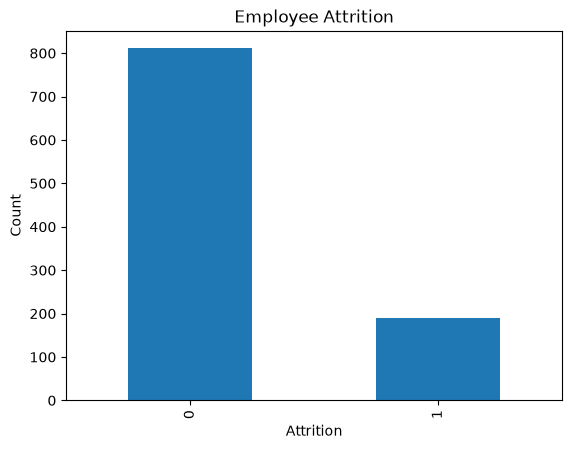

In [23]:
data["Attrition"].value_counts().plot(kind="bar")
plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

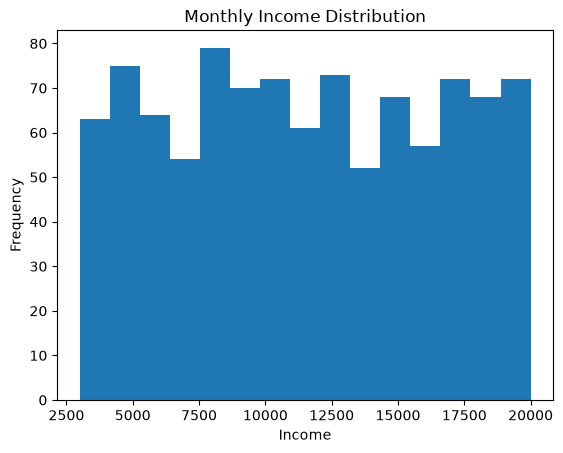

In [24]:
data["Monthly_Income"].plot(kind="hist", bins=15)
plt.title("Monthly Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

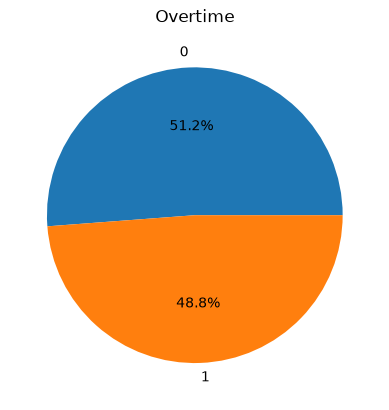

In [25]:
data["Overtime"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Overtime")
plt.ylabel("")
plt.show()

In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

X = data[['Age','Gender','Marital_Status','Department','Job_Role','Job_Level',
          'Monthly_Income','Hourly_Rate','Years_at_Company',
          'Years_in_Current_Role','Years_Since_Last_Promotion',
          'Work_Life_Balance','Job_Satisfaction','Performance_Rating',
          'Training_Hours_Last_Year','Overtime','Project_Count',
          'Average_Hours_Worked_Per_Week','Absenteeism',
          'Work_Environment_Satisfaction','Relationship_with_Manager',
          'Job_Involvement','Distance_From_Home',
          'Number_of_Companies_Worked']]

y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
prediction = model.predict([[
30,      
1,       
0,       
2,       
3,       
2,       
50000,   
150,     
5,      
3,      
1,       
3,       
4,       
3,      
20,    
1,      
4,      
45,      
2,       
4,       
3,       
3,       
10,    
2        
]])

print("Prediction:", prediction)

accuracy_lr = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_lr)

Prediction: [0]
Accuracy: 0.845


C:\Users\garvit\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\garvit\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [20]:
from sklearn.tree import DecisionTreeClassifier

for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

X = data[['Age','Gender','Marital_Status','Department','Job_Role','Job_Level',
          'Monthly_Income','Hourly_Rate','Years_at_Company',
          'Years_in_Current_Role','Years_Since_Last_Promotion',
          'Work_Life_Balance','Job_Satisfaction','Performance_Rating',
          'Training_Hours_Last_Year','Overtime','Project_Count',
          'Average_Hours_Worked_Per_Week','Absenteeism',
          'Work_Environment_Satisfaction','Relationship_with_Manager',
          'Job_Involvement','Distance_From_Home',
          'Number_of_Companies_Worked']]

y = data['Attrition']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


prediction = model.predict([[
30,
1,
0,
2,
3,
2,
50000,
150,
5,
3,
1,
3,
4,
3,
20,
1,
4,
45,
2,
4,
3,
3,
10,
2
]])


print("Prediction:", prediction)

accuracy_dtc = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_dtc)


Prediction: [1]
Accuracy: 0.7


C:\Users\garvit\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [21]:
from sklearn.ensemble import RandomForestClassifier

for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

X = data[['Age','Gender','Marital_Status','Department','Job_Role','Job_Level',
          'Monthly_Income','Hourly_Rate','Years_at_Company',
          'Years_in_Current_Role','Years_Since_Last_Promotion',
          'Work_Life_Balance','Job_Satisfaction','Performance_Rating',
          'Training_Hours_Last_Year','Overtime','Project_Count',
          'Average_Hours_Worked_Per_Week','Absenteeism',
          'Work_Environment_Satisfaction','Relationship_with_Manager',
          'Job_Involvement','Distance_From_Home',
          'Number_of_Companies_Worked']]

y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

prediction = model.predict([[
30,
1,
0,
2,
3,
2,
50000,
150,
5,
3,
1,
3,
4,
3,
20,
1,
4,
45,
2,
4,
3,
3,
10,
2
]])
print("Prediction:", prediction)

accuracy_rfc = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_rfc)

Prediction: [0]
Accuracy: 0.845


C:\Users\garvit\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


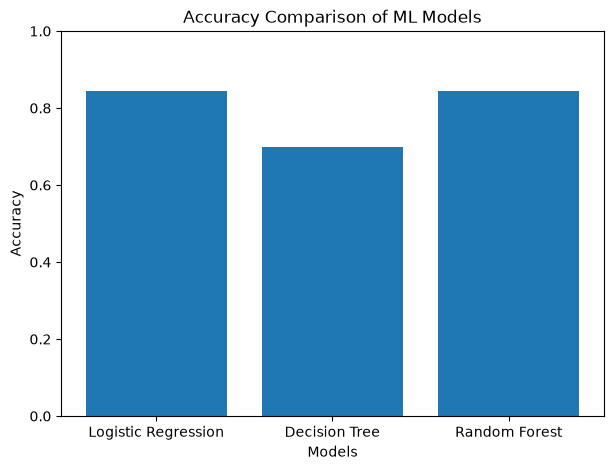

In [22]:
import matplotlib.pyplot as plt
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [accuracy_lr, accuracy_dtc, accuracy_rfc]
plt.figure(figsize=(7,5))
plt.bar(models, accuracy)

plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()